In [15]:
# used for mathematical opertion
import numpy as np

In [16]:
# used for data cleaning and data manipulation
import pandas as pd

In [17]:
# used for understanding the data with the help of graph
import matplotlib.pyplot as plt

In [18]:
# used for data visulation through heatmap and boxplot
import seaborn as sns

In [19]:
# used for training and testing the data
from sklearn.model_selection import train_test_split

In [20]:
# this library is generaly use for converting text into numbers
from sklearn.preprocessing import LabelEncoder

In [21]:
# used to evaluate model performance
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [22]:
# linear regression is use analyze the relation between the variables by fitting a straight line to the data
from sklearn.linear_model import LinearRegression

In [23]:
# it improve the accuracy by combining the predictions of multiple decision tree
from sklearn.ensemble import RandomForestRegressor

In [24]:
# loding the dataset
df = pd.read_csv("car_ML_model.csv")

In [25]:
# it will show the first 5 row
df.head()

,Brand,Model,Year,KM_Driven,Fuel_Type,Mileage,Transmission,Owner_Type,Engine,Seats,Selling_Price
0,Toyota,Innova,2017,67232.0,Petrol,28.7,Automatic,Third Owner,796.0,5,565388
1,Kia,Carens,2019,53101.0,Petrol,15.8,Automatic,Third Owner,1248.0,6,659550
2,Tata,Punch,2019,198125.0,Diesel,16.7,Manual,Third Owner,2179.0,7,531045
3,Maruti,WagonR,2015,129325.0,Diesel,20.8,Manual,Third Owner,1248.0,5,342231
4,Kia,Carens,2019,131040.0,Petrol,20.3,Automatic,First Owner,2179.0,5,639789


In [26]:
# it will show the last 5 row
df.tail()

,Brand,Model,Year,KM_Driven,Fuel_Type,Mileage,Transmission,Owner_Type,Engine,Seats,Selling_Price
11995,Honda,City,2022,58641.0,CNG,18.9,Manual,Third Owner,998.0,7,725571
11996,Mahindra,Bolero,2018,11376.0,Diesel,15.1,Automatic,Second Owner,1248.0,5,690810
11997,Hyundai,Verna,2013,190711.0,Petrol,18.5,Manual,Second Owner,NaN,7,252628
11998,Maruti,WagonR,2022,103982.0,Diesel,28.8,Automatic,Third Owner,2179.0,7,891370
11999,Tata,Harrier,2014,53516.0,CNG,22.7,Manual,Third Owner,1497.0,7,478961


In [27]:
# number of column and row
df.shape

(12000, 11)

In [28]:
# it will show all features name
df.columns

Index(['Brand', 'Model', 'Year', 'KM_Driven', 'Fuel_Type', 'Mileage',
       'Transmission', 'Owner_Type', 'Engine', 'Seats', 'Selling_Price'],
      dtype='object')

In [29]:
# it will show the data type and number of missing values in each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Brand          12000 non-null  object 
 1   Model          12000 non-null  object 
 2   Year           12000 non-null  int64  
 3   KM_Driven      11998 non-null  float64
 4   Fuel_Type      12000 non-null  object 
 5   Mileage        11999 non-null  float64
 6   Transmission   12000 non-null  object 
 7   Owner_Type     12000 non-null  object 
 8   Engine         11993 non-null  float64
 9   Seats          12000 non-null  int64  
 10  Selling_Price  12000 non-null  int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 1.0+ MB


In [30]:
# checking missing values
df.isnull().sum()

,0
Brand,0
Model,0
Year,0
KM_Driven,2
Fuel_Type,0
Mileage,1
Transmission,0
Owner_Type,0
Engine,7
Seats,0


In [31]:
# for replacing null values with mean values
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_3718/128293851.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [32]:
# check duplicates
df.duplicated().sum()

np.int64(0)

In [33]:
# for checking number of categorical column
df.select_dtypes(include="object").columns

Index(['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type'], dtype='object')

In [34]:
le_brand = LabelEncoder()
le_model = LabelEncoder()
le_fuel = LabelEncoder()
le_trans = LabelEncoder()
le_owner = LabelEncoder()

In [35]:
df['Brand'] = le_brand.fit_transform(df['Brand'])

df['Model'] = le_model.fit_transform(df['Model'])

df['Fuel_Type'] = le_fuel.fit_transform(df['Fuel_Type'])

df['Transmission'] = le_trans.fit_transform(df['Transmission'])

df['Owner_Type'] = le_owner.fit_transform(df['Owner_Type'])

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Brand          12000 non-null  int64  
 1   Model          12000 non-null  int64  
 2   Year           12000 non-null  int64  
 3   KM_Driven      12000 non-null  float64
 4   Fuel_Type      12000 non-null  int64  
 5   Mileage        12000 non-null  float64
 6   Transmission   12000 non-null  int64  
 7   Owner_Type     12000 non-null  int64  
 8   Engine         12000 non-null  float64
 9   Seats          12000 non-null  int64  
 10  Selling_Price  12000 non-null  int64  
dtypes: float64(3), int64(8)
memory usage: 1.0 MB


In [37]:
df.head()

,Brand,Model,Year,KM_Driven,Fuel_Type,Mileage,Transmission,Owner_Type,Engine,Seats,Selling_Price
0,6,11,2017,67232.0,2,28.7,0,2,796.0,5,565388
1,2,4,2019,53101.0,2,15.8,0,2,1248.0,6,659550
2,5,14,2019,198125.0,1,16.7,1,2,2179.0,7,531045
3,4,23,2015,129325.0,1,20.8,1,2,1248.0,5,342231
4,2,4,2019,131040.0,2,20.3,0,0,2179.0,5,639789


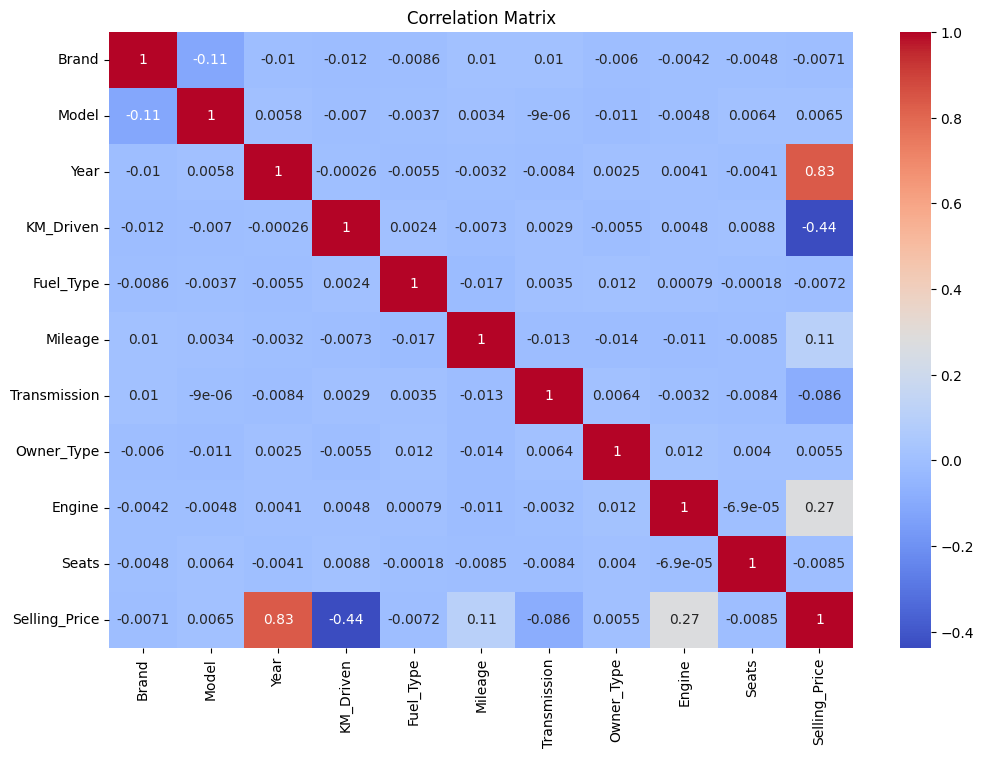

In [38]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [39]:
# car_age
current_year = 2026

df["Car_Age"] = current_year - df["Year"]

In [40]:
# car used by the user
df["KM_Per_Year"] = df["KM_Driven"] / df["Car_Age"]

In [41]:
# price per engine
df["Engine_Per_Seat"] = df["Engine"] / df["Seats"]

In [42]:
# simple linear regression
X = df[["Car_Age"]]

y = df["Selling_Price"]

In [43]:
# train and test the data


X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
# creating my own class


class car_ML:

    def __init__(self, lr=0.001, epochs=1000):

        self.lr = lr
        self.epochs = epochs

        self.beta0 = 0
        self.beta1 = 0

    def fit(self, X, y):

        n = len(X)

        X = np.array(X).flatten()
        y = np.array(y)

        for i in range(self.epochs):

            y_pred = self.beta0 + self.beta1 * X

            dbeta0 = (-2/n) * np.sum(y - y_pred)

            dbeta1 = (-2/n) * np.sum(
                X * (y - y_pred)
            )

            self.beta0 -= self.lr * dbeta0

            self.beta1 -= self.lr * dbeta1

    def predict(self, X):

        X = np.array(X).flatten()

        return self.beta0 + self.beta1 * X

In [45]:
# train the slr
slr_model = MySLR(
    lr=0.001,
    epochs=5000
)

slr_model.fit(
    X_train,
    y_train
)

In [46]:
# test the prediction
y_pred_slr = slr_model.predict(
    X_test
)

In [47]:
print("Intercept:", slr_model.beta0)

print("Slope:", slr_model.beta1)

Intercept: 762582.7739858109
Slope: -26770.780269360617


In [51]:
# multiple linear regression
X = df.drop(
    ["Selling_Price","Mileage","Transmission"],
    axis=1
)

y = df["Selling_Price"]

In [49]:
df.head()

,Brand,Model,Year,KM_Driven,Fuel_Type,Mileage,Transmission,Owner_Type,Engine,Seats,Selling_Price,Car_Age,KM_Per_Year,Engine_Per_Seat
0,6,11,2017,67232.0,2,28.7,0,2,796.0,5,565388,9,7470.222222,159.200000
1,2,4,2019,53101.0,2,15.8,0,2,1248.0,6,659550,7,7585.857143,208.000000
2,5,14,2019,198125.0,1,16.7,1,2,2179.0,7,531045,7,28303.571429,311.285714
3,4,23,2015,129325.0,1,20.8,1,2,1248.0,5,342231,11,11756.818182,249.600000
4,2,4,2019,131040.0,2,20.3,0,0,2179.0,5,639789,7,18720.000000,435.800000


In [52]:
# feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [54]:
# train testX_train,X_test,y_train,y_test = train_test_split(
X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [55]:
# creating my own MLR class
class car_cost:

    def __init__(
        self,
        lr=0.001,
        epochs=5000
    ):

        self.lr = lr
        self.epochs = epochs

        self.beta0 = 0
        self.beta = None

    def fit(self,X,y):

        n_samples = X.shape[0]

        n_features = X.shape[1]

        self.beta = np.zeros(
            n_features
        )

        for i in range(self.epochs):

            y_pred = (
                np.dot(X,self.beta)
                + self.beta0
            )

            dbeta = (
                -2/n_samples
            ) * np.dot(
                X.T,
                (y-y_pred)
            )

            dbeta0 = (
                -2/n_samples
            ) * np.sum(
                y-y_pred
            )

            self.beta -= (
                self.lr * dbeta
            )

            self.beta0 -= (
                self.lr * dbeta0
            )

    def predict(self,X):

        return (
            np.dot(X,self.beta)
            + self.beta0
        )

In [57]:
# train the mlr
mlr_model = car_cost(
    lr=0.001,
    epochs=5000
)

mlr_model.fit(
    X_train,
    y_train
)

In [58]:
# predict
y_pred_mlr = mlr_model.predict(
    X_test
)

In [59]:
# finding mean absolute error
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test,
    y_pred_mlr
)

print("MAE:", mae)

MAE: 32264.969671030838


In [60]:
# finding mean square error
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    y_test,
    y_pred_mlr
)

print("MSE:", mse)

MSE: 1546409660.9789963


In [61]:
# root mean square error
import numpy as np

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 39324.4155834387


In [83]:
# R2 schore
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred_mlr)

print("R² Score:", r2_mlr)

R² Score: 0.9587356121700905


In [63]:
#  desplay the metrics value together
print("R² Score :", r2)
print("MAE      :", mae)
print("MSE      :", mse)
print("RMSE     :", rmse)

R² Score : 0.9587356121700905
MAE      : 32264.969671030838
MSE      : 1546409660.9789963
RMSE     : 39324.4155834387


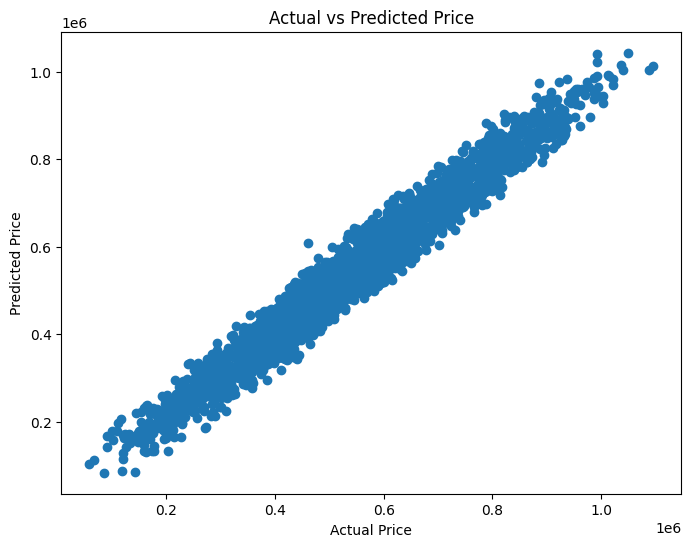

In [67]:
# actual vs prediction scatter plot
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_mlr

)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

In [72]:
# creating random forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [73]:
# train the model
rf_model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

In [74]:
# predict the selling_price
y_pred_rf = rf_model.predict(
    X_test
)

In [75]:
# R2 schore for rf
from sklearn.metrics import r2_score

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("R² Score :", r2_rf)

R² Score : 0.9518744102318519


In [76]:
# mean absalute error
from sklearn.metrics import mean_absolute_error

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

print("MAE :", mae_rf)

MAE : 34759.86495416666


In [77]:
# mean square error
from sklearn.metrics import mean_squared_error

mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

print("MSE :", mse_rf)

MSE : 1803537647.6331325


In [78]:
# root mean square error
import numpy as np

rmse_rf = np.sqrt(
    mse_rf
)

print("RMSE :", rmse_rf)

RMSE : 42468.0779837413


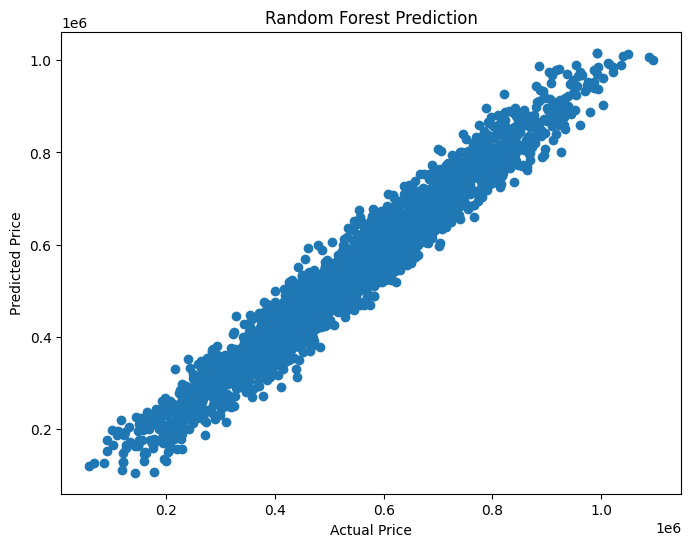

In [79]:
# actual vs prediction value
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Random Forest Prediction")

plt.show()

In [80]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

            Feature  Importance
2              Year    0.358101
8           Car_Age    0.335893
3         KM_Driven    0.198129
6            Engine    0.071617
9       KM_Per_Year    0.010777
1             Model    0.007292
10  Engine_Per_Seat    0.006743
0             Brand    0.004455
4         Fuel_Type    0.002525
5        Owner_Type    0.002500
7             Seats    0.001970


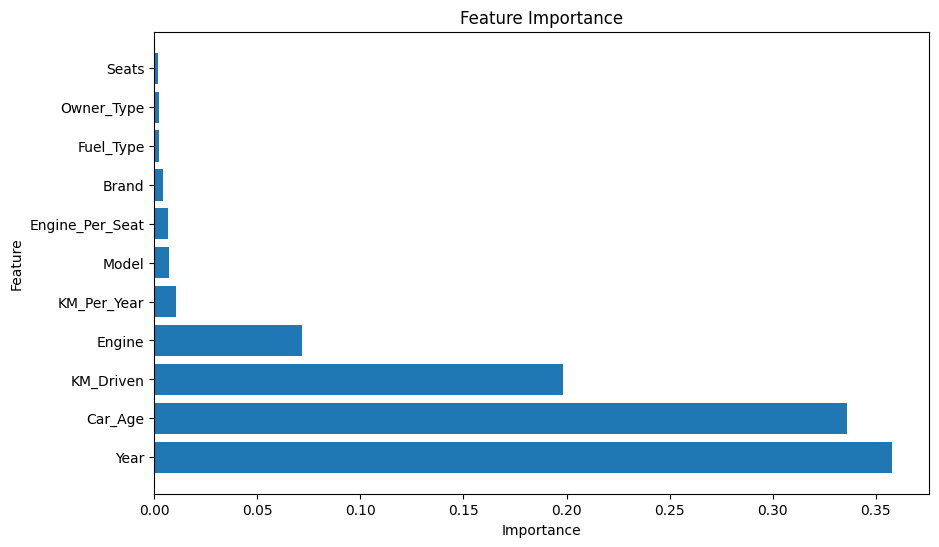

In [81]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Feature Importance")

plt.show()

In [82]:
# compare all model
comparison = pd.DataFrame({

    "Model":[
        "SLR",
        "MLR",
        "Random Forest"
    ],

    "R2 Score":[
        r2_slr,
        r2_mlr,
        r2_rf
    ]

})

comparison

,Model,R2 Score
0,SLR,0.638989
1,MLR,0.958736
2,Random Forest,0.951874


In [84]:
# selecting the best model
best_model = car_cost

In [85]:
# now impoet pickel to save the model
import pickle

with open(
    "car_price_model.pkl",
    "wb"
) as file:

    pickle.dump(
        rf_model,
        file
    )

In [86]:
with open(
    "car_price_model.pkl",
    "rb"
) as file:

    loaded_model = pickle.load(
        file
    )

print("Model Loaded Successfully")

Model Loaded Successfully
